# 1D CNN Tutorial Notebook

This notebook shows how to build, train, and evaluate a simple **1D Convolutional Neural Network (CNN)** for time-series classification using TensorFlow/Keras.

The example uses a synthetic dataset so you can run it immediately, then replace the data-loading section with your own signals later.

In [1]:
# ==============================
# 1. Import the libraries we need
# ==============================
# numpy: numerical arrays and random number generation
# matplotlib: plotting sample signals and training curves
# sklearn: train/test split and evaluation metrics
# tensorflow.keras: model definition and training

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Make the random results reproducible
np.random.seed(42)

I0000 00:00:1776913277.064862   39049 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776913277.065552   39049 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776913277.121931   39049 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776913278.560222   39049 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
# =========================================
# 2. Create a synthetic 1D signal dataset
# =========================================
# We will generate two classes of signals:
# - Class 0: sine waves with one frequency pattern
# - Class 1: sine waves with a different frequency pattern
#
# Each sample is a 1D sequence, which makes it suitable for Conv1D.
# In real projects, this section is where you would load sensor data,
# audio features, ECG traces, or other time-series samples.

n_samples = 1000         # total number of sequences
sequence_length = 128    # number of time steps in each sequence
n_classes = 2            # binary classification

X = []
y = []

for i in range(n_samples):
    t = np.linspace(0, 1, sequence_length)
    noise = np.random.normal(0, 0.15, sequence_length)

    # First half of the samples belong to class 0
    if i < n_samples // 2:
        signal = np.sin(2 * np.pi * 5 * t) + noise
        label = 0
    # Second half belong to class 1
    else:
        signal = np.sin(2 * np.pi * 9 * t) + noise
        label = 1

    X.append(signal)
    y.append(label)

X = np.array(X)
y = np.array(y)

print('X shape before channel dimension:', X.shape)
print('y shape:', y.shape)

X shape before channel dimension: (1000, 128)
y shape: (1000,)


In [3]:
# ============================================
# 3. Prepare the data for a 1D CNN model
# ============================================
# Conv1D expects input in the shape:
# (samples, time_steps, channels)
#
# Right now, X has shape (samples, time_steps).
# We add one channel because each signal currently has only one feature
# at each time step.

X = X[..., np.newaxis]

# Convert labels to one-hot format for categorical classification
y_encoded = to_categorical(y, num_classes=n_classes)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y
)

print('X shape after channel dimension:', X.shape)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)

X shape after channel dimension: (1000, 128, 1)
X_train shape: (800, 128, 1)
X_test shape: (200, 128, 1)
y_train shape: (800, 2)


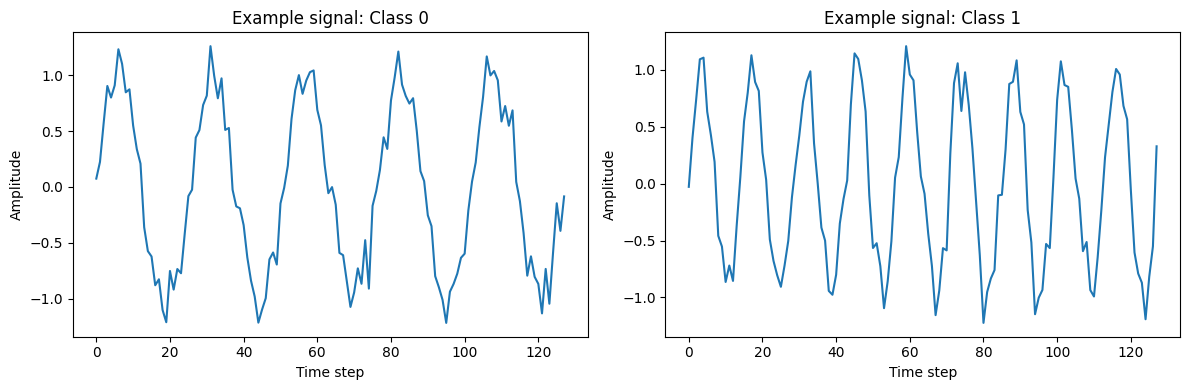

In [4]:
# =================================
# 4. Visualize a few input signals
# =================================
# This helps confirm that the classes look different enough for the
# network to learn a useful pattern.

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(X[y == 0][0].squeeze())
plt.title('Example signal: Class 0')
plt.xlabel('Time step')
plt.ylabel('Amplitude')

plt.subplot(1, 2, 2)
plt.plot(X[y == 1][0].squeeze())
plt.title('Example signal: Class 1')
plt.xlabel('Time step')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [5]:
# =========================
# 5. Build the 1D CNN model
# =========================
# The main idea behind Conv1D:
# - Convolution layers scan along the time axis
# - Filters learn local temporal patterns
# - Pooling reduces sequence size and keeps the strongest features
# - Dense layers perform the final classification

model = Sequential([
    # First convolution layer:
    # 32 filters, kernel size 3 means each filter looks at 3 time steps at once
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(sequence_length, 1)),

    # Pooling reduces the time dimension by taking the maximum in each window
    MaxPooling1D(pool_size=2),

    # A second convolution layer can learn more complex patterns
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Flatten converts the 3D feature maps into a 1D vector
    Flatten(),

    # Dense layer learns combinations of the extracted features
    Dense(64, activation='relu'),

    # Dropout helps reduce overfitting by randomly dropping neurons during training
    Dropout(0.3),

    # Final layer uses softmax for multi-class classification
    Dense(n_classes, activation='softmax')
])

# Compile the model:
# - optimizer='adam' updates the weights efficiently
# - loss='categorical_crossentropy' is suitable for one-hot labels
# - accuracy lets us track classification performance during training
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/home/jestin/ThesisRepo/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776913280.298182   39049 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_INVALID_DEVICE: invalid device ordinal
I0000 00:00:1776913280.298243   39049 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1776913280.298248   39049 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: jestin-OMEN-Gaming-Laptop-16-am0xxx
I0000 00:00:1776913280.298254   39049 cuda_diagnostics.cc:183] hostname: jestin-OMEN-Gaming-Lapto

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       122,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,410 (505.51 KB)

 Trainable params: 129,410 (505.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ====================
# 6. Train the model
# ====================
# We train for a small number of epochs so the notebook runs quickly.
# validation_split=0.2 means 20% of the training data is used for
# validation during training.

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9703 - loss: 0.1430 - val_accuracy: 1.0000 - val_loss: 1.9520e-04
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 2.2789e-04 - val_accuracy: 1.0000 - val_loss: 4.6909e-06
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 4.2733e-05 - val_accuracy: 1.0000 - val_loss: 2.2918e-06
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 4.2817e-05 - val_accuracy: 1.0000 - val_loss: 1.9282e-06
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 2.6117e-05 - val_accuracy: 1.0000 - val_loss: 1.7464e-06
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 2.1459e-05 - val_accuracy: 1.0000 - val_loss: 1.6302e-06
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 2.2882e-05 - val_accuracy: 1.0000 - val_loss: 1.5140e-06
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accura

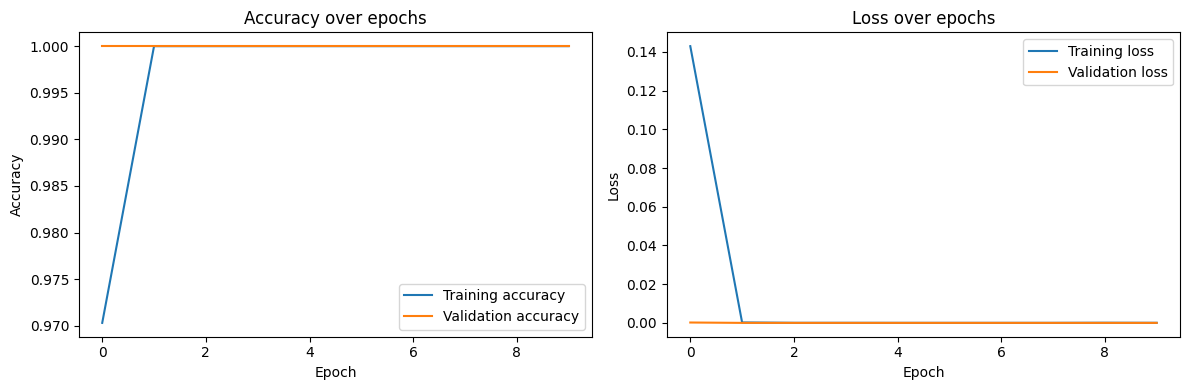

In [7]:
# ====================================
# 7. Plot training and validation loss
# ====================================
# These curves help you diagnose training behavior:
# - If both improve, training is working
# - If training improves but validation gets worse, you may be overfitting

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# ========================
# 8. Evaluate the model
# ========================
# First, evaluate overall loss and accuracy on the held-out test set.

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss: 0.0000
Test accuracy: 1.0000


In [9]:
# ============================================
# 9. Generate predictions and detailed metrics
# ============================================
# We convert predicted probabilities into class labels using argmax.

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))

print('\nClassification Report:')
print(classification_report(y_true, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Confusion Matrix:
[[100   0]
 [  0 100]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## How to adapt this notebook to your own data

Replace the synthetic dataset section with your real dataset and keep the same shape convention:

- `X` should have shape `(samples, time_steps, channels)`
- `y` should contain the class labels
- If you have a single sensor per time step, `channels = 1`
- If you have multiple sensors/features per time step, `channels` can be greater than 1

Common examples for 1D CNNs include ECG classification, activity recognition from IMU data, vibration analysis, and generic time-series classification.